# Cart–pendulum LQR using a **position slider** (setpoint), explained

This notebook is the same idea as `LQR-pendulum.ipynb`, but the actuator is different:

- **Force motor version**: `ctrl` = force on the cart (Newtons).
- **Position slider version (this notebook)**: `ctrl` = desired cart position (meters).

So LQR will output a **target cart position** each timestep.

Important note: a position actuator is already a small feedback controller inside MuJoCo (it tries to track the setpoint using `kp`/`kv`).
Here, LQR is the *outer* controller that chooses the setpoint.


## 1) Imports and display setup

In [1]:
# pip install mujoco mediapy matplotlib scipy

import os
import sys

import numpy as np
import scipy.linalg
import mujoco

if sys.platform == "win32" and "MUJOCO_GL" not in os.environ:
    os.environ.setdefault("MUJOCO_GL", "glfw")

import matplotlib.pyplot as plt

try:
    import mediapy as media
except ImportError:
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "mediapy"])
    import mediapy as media

import shutil
from IPython.display import HTML, display
from matplotlib import animation as mpl_animation

if not shutil.which("ffmpeg"):
    def _show_video_matplotlib(frames, fps=30, **kwargs):
        fig, ax = plt.subplots()
        ax.axis("off")
        im = ax.imshow(frames[0])
        interval_ms = 1000 / fps if fps else 33

        def _update(i):
            im.set_data(frames[i])
            return [im]

        ani = mpl_animation.FuncAnimation(
            fig, _update, frames=len(frames), interval=interval_ms, blit=True
        )
        plt.close(fig)
        display(HTML(ani.to_jshtml()))

    media.show_video = _show_video_matplotlib

np.set_printoptions(precision=3, suppress=True, linewidth=100)


## 2) Model XML (position actuator)

`<position ...>` makes `ctrl[0]` mean: **desired cart position** in meters.

We keep `integrator="implicitfast"` because MuJoCo's `mjd_transitionFD` (used for linearization) does not support RK4.


In [2]:
xml = """<mujoco model="cart_pendulum">
  <compiler angle="radian" autolimits="true"/>
  <option timestep="0.004166666666666667" gravity="0 0 -9.80665" integrator="implicitfast"/>

  <default>
    <joint damping="0.04" armature="0.001"/>
    <geom rgba="0.55 0.55 0.6 1" friction="0.2 0.05 0.001"/>
  </default>

  <worldbody>
    <light name="main_light" pos="0 -1 1" dir="0 1 -1" diffuse="1 1 1"/>
    <camera name="side" pos="0 -1.2 0.35" xyaxes="1 0 0 0 0 1"/>

    <geom name="rail" type="box" size="1 0.02 0.01" pos="0 0 0"
          rgba="0.35 0.35 0.4 1" contype="0" conaffinity="0"/>

    <body name="cart" pos="0 0 0.05">
      <joint name="cart_slide" type="slide" axis="1 0 0" damping="0.5" limited="false"/>
      <geom name="cart_geom" type="box" size="0.06 0.04 0.03" mass="0.8"/>

      <body name="pendulum" pos="0 0 0">
        <joint name="pendulum_hinge" type="hinge" axis="0 1 0" pos="0 0 0"/>
        <geom name="rod" type="capsule" fromto="0 0 0 0 0 -0.35" size="0.004" mass="0.12"/>
        <geom name="bob" type="sphere" size="0.03" pos="0 0 -0.35" mass="0.12"/>
      </body>
    </body>
  </worldbody>

  <actuator>
    <!-- ctrl = desired cart position (m). kp/kv make the joint track the setpoint. -->
    <position name="cart_pos" joint="cart_slide" kp="1200" kv="120"
              ctrllimited="true" ctrlrange="-1.0 1.0"/>
  </actuator>

  <keyframe>
    <!-- qpos = [cart_slide, pendulum_hinge]; ctrl = cart position setpoint (m) -->
    <key name="upright_0deg" qpos="0 3.14159265359" ctrl="0"/>
    <key name="upright_2deg" qpos="0 3.17649923863" ctrl="0"/>
    <key name="upright_minus_45deg" qpos="0 2.356194490" ctrl="0"/>
    <key name="upright_minus_30deg" qpos="0 2.617993878" ctrl="0"/>
  </keyframe>
</mujoco>
"""

## 3) Load model and define the "goal" (upright) setpoint

- `qpos0` is the pose we want (upright).
- `ctrl0` is the cart setpoint we want at the goal pose (usually 0 meters).

For a position actuator, `ctrl0` is just the **cart x-position we want**.

In [3]:
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, "upright_0deg")
mujoco.mj_resetDataKeyframe(model, data, key_id)
qpos0 = data.qpos.copy()

# Baseline cart target (m). Here we hold the cart at its goal x position.
cart_qpos_adr = model.joint("cart_slide").qposadr[0]
ctrl0 = np.array([float(qpos0[cart_qpos_adr])])

camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2

print("Goal qpos0:", qpos0)
print("Baseline ctrl0 (m):", ctrl0)


Goal qpos0: [0.    3.142]
Baseline ctrl0 (m): [0.]


## 4) Choose Q and R ("what we care about")

The error vector is:

`dx = [cart position error, pendulum angle error, cart velocity, pendulum angular velocity]`

Because our control input is a **position setpoint**, the meaning of `R` is "don't move the target too aggressively".


In [4]:
nu = model.nu
nv = model.nv

Q = np.diag([
    500.0,     # cart position
    100.0,   # pendulum angle (most important)
    1.0,     # cart velocity
    10.0,    # pendulum angular velocity
])

# Penalize moving the setpoint too much.
R = 0.05 * np.eye(nu)

print("Q diagonal:", np.diag(Q))
print("R:", R)


Q diagonal: [500. 100.   1.  10.]
R: [[0.05]]


## 5) Linearize dynamics around (qpos0, ctrl0)

`mjd_transitionFD` does the "small nudges" experiments automatically and returns discrete-time A and B.


In [5]:
mujoco.mj_resetData(model, data)
data.qpos = qpos0
data.qvel[:] = 0
data.ctrl = ctrl0

A = np.zeros((2 * nv, 2 * nv))
B = np.zeros((2 * nv, nu))
mujoco.mjd_transitionFD(model, data, 1e-6, True, A, B, None, None)

print("A", A.shape, "B", B.shape)


A (4, 4) B (4, 1)


## 6) Solve for K

After this cell, `K` tells us how to convert the 4 error numbers into a change in the cart position target.


In [6]:
P = scipy.linalg.solve_discrete_are(A, B, Q, R)
K = np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A
print("K =", K)


K = [[-1.617 -1.366 -0.513 -0.224]]


## 7) Simulate (closed loop)

Control loop each step:

1. Measure error `dx` vs goal.
2. Compute new target position: `ctrl = ctrl0 - K @ dx`.
3. Clamp to actuator limits.
4. Step physics.

We start at `upright_2deg` (2 degrees off upright) to test stabilization.


In [10]:
DURATION = 2
FRAMERATE = 60

# Start slightly perturbed from upright.
# (If your XML doesn't include this keyframe, switch to "upright_2deg".)
key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, "upright_minus_30deg")
mujoco.mj_resetDataKeyframe(model, data, key_id)
data.qvel[:] = 0

dq = np.zeros(nv)
ctrlrange = model.actuator_ctrlrange[0]  # [min_setpoint_m, max_setpoint_m]

# Indices into qpos for convenience.
pend_adr = model.joint("pendulum_hinge").qposadr[0]

# We'll record what command we send so we can plot it later.
t_hist = []
ctrl_hist = []        # commanded cart target (m)
cart_hist = []        # actual cart position (m)
pend_hist_deg = []    # pendulum angle error from upright (degrees)

frames = []
while data.time < DURATION:
    # --- measure error ---
    mujoco.mj_differentiatePos(model, dq, 1, qpos0, data.qpos)
    dx = np.hstack((dq, data.qvel))

    # --- LQR chooses a new cart position target (meters) ---
    target_m = float((ctrl0 - K @ dx).squeeze())
    target_m = float(np.clip(target_m, ctrlrange[0], ctrlrange[1]))
    data.ctrl[0] = target_m

    # --- record command + state (for plotting) ---
    t_hist.append(float(data.time))
    ctrl_hist.append(float(data.ctrl[0]))
    cart_hist.append(float(data.qpos[cart_qpos_adr]))
    pend_hist_deg.append(float(np.degrees(data.qpos[pend_adr] - np.pi)))

    # step physics
    mujoco.mj_step(model, data)

    # render frames
    if len(frames) < data.time * FRAMERATE:
        renderer.update_scene(data, camera)
        frames.append(renderer.render())

tilt_deg = np.degrees(data.qpos[pend_adr] - np.pi)
print(f"Final tilt from upright: {tilt_deg:.2f} deg")
print(f"Final cart position: {data.qpos[cart_qpos_adr]:.4f} m")
media.show_video(frames, fps=FRAMERATE)


Final tilt from upright: 0.07 deg
Final cart position: 0.0020 m


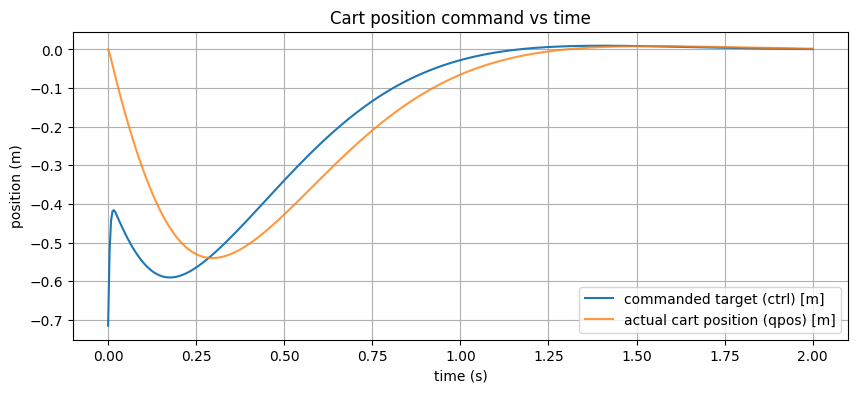

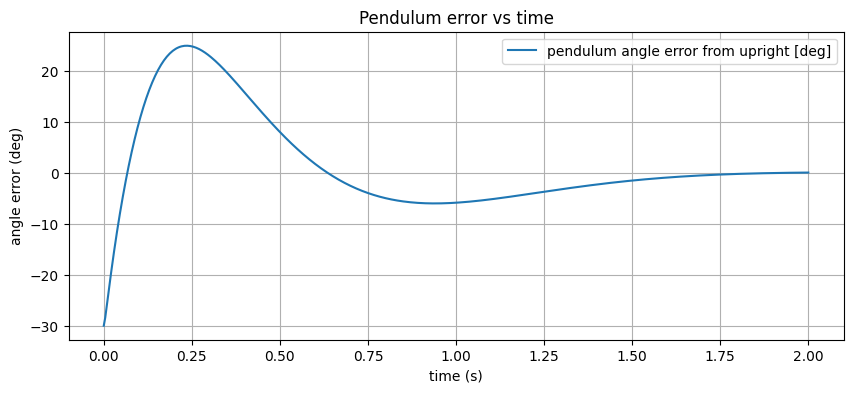

In [11]:
# These plots answer two beginner-friendly questions:
#
# 1) "What did the controller ask the cart to do?"
#    - That's the commanded target position: ctrl(t)
#
# 2) "Did it work?"
#    - If the pendulum error stays near 0 degrees, the pendulum stayed upright.
#
# ----------------------------
# Plot 1: Cart command vs cart motion
# ----------------------------
# X axis: time in seconds.
# Y axis: position in meters.
#
# - "commanded target (ctrl)": the *goal* position we ask the cart to go to.
# - "actual cart position (qpos)": where the cart *really is*.
#
# What to look for:
# - If the two curves are close: the cart is following the command well.
# - If they are far apart: the cart cannot keep up (maybe kp/kv too small, or command too aggressive).

plt.figure(figsize=(10, 4))
plt.plot(t_hist, ctrl_hist, label="commanded target (ctrl) [m]")
plt.plot(t_hist, cart_hist, label="actual cart position (qpos) [m]", alpha=0.8)
plt.xlabel("time (s)")
plt.ylabel("position (m)")
plt.title("Cart command (target) vs actual cart position")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Plot 2: Pendulum upright error
# ----------------------------
# This shows how "not-upright" the pendulum is.
#
# - 0 degrees means perfectly upright.
# - Positive vs negative just means it leans to different sides.
# - The *size* (absolute value) is what matters.
#
# What to look for:
# - Good balance: the curve quickly goes toward 0 and stays near 0.
# - Poor balance: the curve grows larger (the pendulum is falling).

plt.figure(figsize=(10, 4))
plt.plot(t_hist, pend_hist_deg, label="pendulum angle error from upright [deg]")
plt.axhline(0, color="black", linewidth=1, alpha=0.6)
plt.xlabel("time (s)")
plt.ylabel("angle error (deg)")
plt.title("How upright is the pendulum? (0° = upright)")
plt.grid(True)
plt.legend()
plt.show()